In [22]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
import os
load_dotenv()
from langgraph.checkpoint.memory import InMemorySaver

In [23]:
api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key, model="llama-3.1-8b-instant")

In [24]:
class jokeGenrate(TypedDict):

    topic: str
    joke: str
    explanation:str

In [25]:
def gen_joke(state: jokeGenrate):

    prompt = f"genarate a joke of this topic- {state['topic']}"

    response = llm.invoke(prompt)

    return {'joke': response}

In [26]:
def gen_expl(state: jokeGenrate):

    prompt=  f"write a explaination of the joke - {state['joke']}"

    response = llm.invoke(prompt)

    return {'explanation': response}

In [27]:
graph = StateGraph(jokeGenrate)

graph.add_node('gen_joke',gen_joke)
graph.add_node('gen_expl',gen_expl)

graph.add_edge(START, 'gen_joke')
graph.add_edge('gen_joke', 'gen_expl')
graph.add_edge('gen_expl', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
print(workflow)

In [28]:
One_1 = {"configurable": {"thread_id": "One_1"}}
workflow.invoke({'topic': 'vada'},config=One_1)

{'topic': 'vada',
 'joke': AIMessage(content="Why did the vada go to therapy?\n\nBecause it was feeling 'deep-fried' under the pressure.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 46, 'total_tokens': 69, 'completion_time': 0.034705823, 'prompt_time': 0.002182071, 'queue_time': 0.055828689, 'total_time': 0.036887894}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--b58d0ed1-9fe6-41ae-90c8-d415e9653aa3-0', usage_metadata={'input_tokens': 46, 'output_tokens': 23, 'total_tokens': 69}),
 'explanation': AIMessage(content='**Joke Explanation:**\n\nThe joke is a play on words, using a pun to create humor. It starts with a question, "Why did the vada go to therapy?" which is a setup for a typical joke. The punchline is, "Because it was feeling \'deep-fried\' under the pressure."\n\nIn this joke, "vada" is a type of Indian fried 

In [29]:
workflow.get_state(One_1)

StateSnapshot(values={'topic': 'vada', 'joke': AIMessage(content="Why did the vada go to therapy?\n\nBecause it was feeling 'deep-fried' under the pressure.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 46, 'total_tokens': 69, 'completion_time': 0.034705823, 'prompt_time': 0.002182071, 'queue_time': 0.055828689, 'total_time': 0.036887894}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--b58d0ed1-9fe6-41ae-90c8-d415e9653aa3-0', usage_metadata={'input_tokens': 46, 'output_tokens': 23, 'total_tokens': 69}), 'explanation': AIMessage(content='**Joke Explanation:**\n\nThe joke is a play on words, using a pun to create humor. It starts with a question, "Why did the vada go to therapy?" which is a setup for a typical joke. The punchline is, "Because it was feeling \'deep-fried\' under the pressure."\n\nIn this joke, "vada" is a ty

In [30]:
list(workflow.get_state_history(One_1))

[StateSnapshot(values={'topic': 'vada', 'joke': AIMessage(content="Why did the vada go to therapy?\n\nBecause it was feeling 'deep-fried' under the pressure.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 46, 'total_tokens': 69, 'completion_time': 0.034705823, 'prompt_time': 0.002182071, 'queue_time': 0.055828689, 'total_time': 0.036887894}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--b58d0ed1-9fe6-41ae-90c8-d415e9653aa3-0', usage_metadata={'input_tokens': 46, 'output_tokens': 23, 'total_tokens': 69}), 'explanation': AIMessage(content='**Joke Explanation:**\n\nThe joke is a play on words, using a pun to create humor. It starts with a question, "Why did the vada go to therapy?" which is a setup for a typical joke. The punchline is, "Because it was feeling \'deep-fried\' under the pressure."\n\nIn this joke, "vada" is a t

In [37]:
result_02 = {"configurable": {"thread_id": "One_2"}}
workflow.invoke({'topic': 'Kachori'},config=result_02)

{'topic': 'Kachori',
 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}),
 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where the wordplay comes in

In [38]:
workflow.get_state(result_02)

StateSnapshot(values={'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where th

In [39]:
list(workflow.get_state_history(result_02))

[StateSnapshot(values={'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where t

In [40]:
for s in workflow.get_state_history(result_02):
    print("step:", s.metadata["step"], "source:", s.metadata["source"])


step: 6 source: loop
step: 5 source: loop
step: 4 source: loop
step: 3 source: input
step: 2 source: loop
step: 1 source: loop
step: 0 source: loop
step: -1 source: input


In [42]:
for s in workflow.get_state_history(result_02):
    step_num = s.metadata["step"]  # step number nikal lo

    if step_num >= 0:              # number se compare karo
        print("STEP:", step_num)
        print("VALUES:", s.values)
        print("NEXT:", s.next)
        print("-" * 40)

        # jaise hi next empty ho, STOP
        # if not s.next:
        #     break


STEP: 6
VALUES: {'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where the wor

## Time Travel

In [47]:
workflow.get_state({'configurable': {"thread_id": "One_2", 'checkpointer_id':'e30e8ec8-38a8-4ddc-ab19-c87ddbb56dc3-0'}})

StateSnapshot(values={'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where th

In [53]:
workflow.invoke(None,({'configurable': {"thread_id": "One_2", 'checkpointer_id':'e30e8ec8-38a8-4ddc-ab19-c87ddbb56dc3-0'}}))

{'topic': 'Kachori',
 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}),
 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where the wordplay comes in

In [58]:
list(workflow.get_state_history(result_02))

[StateSnapshot(values={'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where t

### update_state

In [59]:
workflow.update_state({'configurable': {"thread_id": "rahul-2", 'checkpointer_id':'1f0adc12-48a6-6888-8000-5b5e21e3ea05',"checkpointer_ns": ""}}, {'topic': 'jalebi'})

{'configurable': {'thread_id': 'rahul-2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0da87e-0e94-6e11-8000-cd0e467d2af6'}}

In [60]:
list(workflow.get_state_history(result_02))

[StateSnapshot(values={'topic': 'Kachori', 'joke': AIMessage(content='Why did the kachori go to therapy?\n\nBecause it was feeling crumby and had a lot of flaky emotions.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 47, 'total_tokens': 74, 'completion_time': 0.040383017, 'prompt_time': 0.002327398, 'queue_time': 0.055599212, 'total_time': 0.042710415}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86584bdc-13c4-4aeb-8301-7dd1e64e3084-0', usage_metadata={'input_tokens': 47, 'output_tokens': 27, 'total_tokens': 74}), 'explanation': AIMessage(content='The joke is a play on words. It starts by asking a question about why a kachori (a type of Indian fried dough pastry) went to therapy. The punchline explains that the kachori went to therapy because it was "feeling crumby" and had "a lot of flaky emotions."\n\nHere\'s where t

In [ ]:
workflow.invoke(None,{'configurable': {"thread_id": "rahul-1", 'checkpointer_id':'1f0adc27-e474-60e2-8003-1fd257a28057'}})

## Foult Tolerance 

In [61]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
import time
from langgraph.checkpoint.memory import InMemorySaver

In [62]:
class CrashState(TypedDict):

    input: str
    step_1: str
    step_2: str
    step_3: str

In [63]:
def step_1(state: CrashState)-> CrashState:

    print("Step 1 - Exicuted.")
    return {'step_1': 'DONE', 'input': state['input']}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

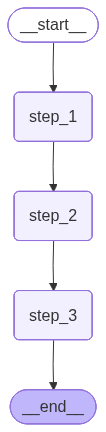

In [64]:
graph = StateGraph(CrashState)


graph.add_node('step_1', step_1)
graph.add_node('step_2', step_2)
graph.add_node('step_3', step_3)

graph.add_edge(START, 'step_1')
graph.add_edge('step_1', 'step_2')
graph.add_edge('step_2', 'step_3')
graph.add_edge('step_3', END)

checkpointer= InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [65]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    workflow.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
Step 1 - Exicuted.
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed


In [66]:
workflow.get_state({'configurable': {'thread_id': 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-548f-6b7e-8003-d62b497ca73c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-16T14:06:46.661004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, tasks=(), interrupts=())

In [67]:
list(workflow.get_state_history({'configurable': {'thread_id': 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-548f-6b7e-8003-d62b497ca73c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-16T14:06:46.661004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-12-16T14:06:46.656504+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da886-365b-6089-8001-7054277c0e47'}}, tasks=(PregelTask(id='3cf5fa47-08d2-d1b9-01c7-0a97e9ed8220', name='step_3', path=('__preg

In [68]:
# resume the workflow 
final_state = workflow.invoke(None,config={"configurable": {"thread_id": "thread-1"}})
print("Final Sate : ", final_state)

Final Sate :  {'input': 'start', 'step_1': 'DONE'}


In [69]:
workflow.get_state({'configurable': {'thread_id': 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-548f-6b7e-8003-d62b497ca73c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-16T14:06:46.661004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, tasks=(), interrupts=())

In [70]:
list(workflow.get_state_history({'configurable': {'thread_id': 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-548f-6b7e-8003-d62b497ca73c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-12-16T14:06:46.661004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step_1': 'DONE'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da887-5484-6bb3-8002-3747af189364'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-12-16T14:06:46.656504+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0da886-365b-6089-8001-7054277c0e47'}}, tasks=(PregelTask(id='3cf5fa47-08d2-d1b9-01c7-0a97e9ed8220', name='step_3', path=('__preg